<div style="background-color: purple; padding: 18px;">
    <h1> Probabilidade e Estatística | Ceub
</div>

### Aluno: Lucas Gonçalves Balduino                                                         
### RA: 22409139

## Contexto


O Campeonato Brasileiro de Futebol, mais conhecido como Brasileirão, tem 20 clubes participantes. 
Nesse campeonato, há jogos em dois turnos, onde jogam todos contra todos. Em cada uma das 38 rodadas há
10 jogos. Cada vitória confere 3 pontos ao vencedor e 0 ponto a quem perde e o empate dá 1 ponto para cada.
Uma prática muito comum, em especial quando os times estão com pouco rendimento, é a troca de técnicos.
Há campeonatos, por exemplo, que mais de uma centena de técnicos sentaram à beira do campo.

## Bibliotecas:

In [42]:
import json
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [22]:
with open('brasileirao-2023.json', 'r', encoding='utf-8') as arquivo:
    dadosDoCampeonato = json.load(arquivo)

## Desafio

0. Dado um arquivo, do tipo JSON, contendo uma infinidade de informações de cada jogo do Brasileirão de 2023, extrair e mostrar
todos os técnicos que estiverem presentes nos jogos.

In [23]:
def carregarDados(conteudoJson):
    if isinstance(conteudoJson, str):
        return json.loads(conteudoJson)
    return conteudoJson

In [ ]:
carregarDados(dadosDoCampeonato)

In [27]:
def todosTecnicos(data):
    tecnicos = set()
    for round_num in data:
        for match in data[round_num]:
            tecnicos.add(match['coach']['home'])
            tecnicos.add(match['coach']['away'])
    return sorted(list(tecnicos))

In [28]:
todosTecnicos(dadosDoCampeonato)

['A. Bacchi',
 'A. C. Pracidelli',
 'A. Cardoso de Oliveira',
 'A. Evangelista Macedo Freitas',
 'A. Ferreira',
 'A. Moreira Ferreira',
 'A. P. Mendes',
 'A. Stival',
 'A. Zago',
 'B. Lazaroni',
 'B. Nascimento',
 'C. Maldonado',
 'C. Salenave Santiago',
 'C. da Silva',
 'D. Aguirre Camblor',
 'D. Giacomini',
 'D. Silvestre Júnior',
 'Danilo',
 'E. Coudet',
 'E. Rodrigues de Ávila',
 'E. de Barros',
 'F. Bustos',
 'F. Diniz Silva',
 'F. Lázaro Rodrigues Alves',
 'F. Paiva Endres',
 'F. Seabra',
 'G. Dalzotto Bossle',
 'I. Abreu Vieira',
 'J. M. Barreto Martins',
 'J. Mannarino',
 'J. Sampaoli Moya',
 'J. Vojvoda',
 'L. Campos Borges',
 'L. De Souza',
 'L. Flávio',
 'L. González',
 'L. Iubel',
 'L. Ribeiro de Castro',
 'L. Scolari',
 'L. Silvestre',
 'L. Venker de Menezes',
 'M. Fernandes',
 'M. Henrique',
 'M. J',
 'M. Nogueira Barbieri',
 'O. Hellmann',
 'P. Autuori de Mello',
 'P. Faria Caixinha',
 'P. Marques da Costa Filipe',
 'P. Turra',
 'R. Alves Paiva',
 'R. Ceni',
 'R. Díaz',


1. Do mesmo arquivo JSON, fazer uma lista dos técnicos mais longevos (isto é, que ficaram mais rodadas na equipe) em cada equipe. Poderá ser uma lista de tuplas, com o nome
do Clube, nome do técnico e o número de partidas que ele comandou aquele clube.

In [31]:
def tecnicoMaisLongevo(dados):
    tecnicosDasEquipes = {}
    
    for round_num in dados:
        for match in dados[round_num]:
            equipeCasa = match['clubs']['home']
            equipeFora = match['clubs']['away']
            tecnicoCasa = match['coach']['home']
            tecnicoFora = match['coach']['away']
            
            if equipeCasa not in tecnicosDasEquipes: tecnicosDasEquipes[equipeCasa] = {}
            if equipeFora not in tecnicosDasEquipes: tecnicosDasEquipes[equipeFora] = {}
            
            tecnicosDasEquipes[equipeCasa][tecnicoCasa] = tecnicosDasEquipes[equipeCasa].get(tecnicoCasa, 0) + 1
            tecnicosDasEquipes[equipeFora][tecnicoFora] = tecnicosDasEquipes[equipeFora].get(tecnicoFora, 0) + 1
            
    # Filtrar o maior para cada equipe
    maisLongevo = []
    for equipe, tecnicos in tecnicosDasEquipes.items():
        # Pega o técnico com mais jogos
        melhorTecnico = max(tecnicos, key=tecnicos.get)
        jogos = tecnicos[melhorTecnico]
        maisLongevo.append((equipe, melhorTecnico, jogos))
        
    return maisLongevo

In [32]:
tecnicoMaisLongevo(dadosDoCampeonato)

[('Palmeiras', 'A. Moreira Ferreira', 32),
 ('Cuiabá', 'A. Cardoso de Oliveira', 28),
 ('América-MG', 'V. Carmo Mancini', 17),
 ('Fluminense', 'F. Diniz Silva', 33),
 ('Botafogo', 'L. Ribeiro de Castro', 11),
 ('São Paulo', 'D. Silvestre Júnior', 35),
 ('Bragantino', 'P. Faria Caixinha', 38),
 ('Bahia', 'R. Alves Paiva', 22),
 ('Athletico-PR', 'W. Carvalho', 28),
 ('Goiás', 'A. Evangelista Macedo Freitas', 23),
 ('Fortaleza', 'J. Vojvoda', 38),
 ('Internacional', 'E. Coudet', 22),
 ('Atlético-MG', 'L. Scolari', 26),
 ('Vasco da Gama', 'R. Díaz', 24),
 ('Corinthians', 'V. Luxemburgo da Silva', 21),
 ('Cruzeiro', 'P. Marques da Costa Filipe', 20),
 ('Flamengo', 'J. Sampaoli Moya', 24),
 ('Coritiba', 'T. Kosloski', 21),
 ('Grêmio', 'Renato Gaúcho', 37),
 ('Santos', 'M. Fernandes', 15)]

2. Do mesmo arquivo, remontar a tabela final do campeonato brasileiro, contendo:
   - Posição (pos)
   - Nome do clube (Equipe)
   - Pontos (Pts)
   - Número de vitórias (V)
   - Número de empates (E)
   - Número de derrotas (D)
   - Gols feitos/Gols pró (GP)
   - Gols sofridos/Gols contra (GC)
   - Saldo de gols (SG)  

Para a classificação, os seguintes critérios definem quem vem primeiro:  
a. Maior pontuação  
b. Número de vitórias  
c. Saldo de gols  
d. Gols pró  
e. Confronto direto  
f. Menos cartões vermelhos  
g. Menos cartões amarelos  
h. Sorteio  

Para esse trabalho, o critério mínimo é até o item d.

3. Baseado no resultado anterior, montar a tabela dada uma rodada específica (variando entre 1 e 38). Nesse caso, após
o número de pontos, incluir o números de jogos (qual rodada) até ali (PJ).

In [56]:
def montarTabela(dados, visualizacao ,rodadaLimite=38):
    # 1. Dicionário para acumular os dados (Lógica original mantida)
    tabela = {}
    
    # Inicializar clubes para garantir que todos apareçam
    for r in dados:
        for m in dados[r]:
            for lado in ['home', 'away']:
                nomeClube = m['clubs'][lado]
                if nomeClube not in tabela:
                    tabela[nomeClube] = {
                        'Equipe': nomeClube, 'Pts': 0, 'J': 0, 'V': 0, 'E': 0, 'D': 0, 
                        'GP': 0, 'GC': 0, 'SG': 0
                    }

    # 2. Processar os jogos
    for numeroInteiro in dados:
        if int(numeroInteiro) > rodadaLimite:
            continue
            
        for partida in dados[numeroInteiro]:
            casa = partida['clubs']['home']
            fora = partida['clubs']['away']
            golsCasa = int(partida['goals']['home'])
            golsFora = int(partida['goals']['away'])
            
            # Atualiza Jogos e Gols
            tabela[casa]['J'] += 1; tabela[fora]['J'] += 1
            tabela[casa]['GP'] += golsCasa; tabela[casa]['GC'] += golsFora
            tabela[casa]['SG'] += (golsCasa - golsFora)
            
            tabela[fora]['GP'] += golsFora; tabela[fora]['GC'] += golsCasa
            tabela[fora]['SG'] += (golsFora - golsCasa)
            
            # Atualiza Pontos e Resultados
            if golsCasa > golsFora:
                tabela[casa]['Pts'] += 3; tabela[casa]['V'] += 1; tabela[fora]['D'] += 1
            elif golsFora > golsCasa:
                tabela[fora]['Pts'] += 3; tabela[fora]['V'] += 1; tabela[casa]['D'] += 1
            else:
                tabela[casa]['Pts'] += 1; tabela[casa]['E'] += 1
                tabela[fora]['Pts'] += 1; tabela[fora]['E'] += 1

    if visualizacao == True:
        # 3. Converter para Pandas (Visualizacao)
        df = pd.DataFrame(list(tabela.values()))
        
        # 4. Ordenar pelos critérios do Brasileirao: Pts > V > SG > GP
        df = df.sort_values(by=['Pts', 'V', 'SG', 'GP'], ascending=False)
        
        # 5. Adicionar coluna de Posicao (1º, 2º, etc)
        df.reset_index(drop=True, inplace=True)
        df.index += 1
        df.index.name = 'Pos'
        
        # 6. Reordenar colunas para ficar visualmente padrao
        colunas_ordem = ['Equipe', 'Pts', 'J', 'V', 'E', 'D', 'GP', 'GC', 'SG']
        df = df[colunas_ordem]
        
        return df
    
    else:
        tabelaOrdenada = []
        for club, stats in tabela.items():
            linha = stats.copy()
            linha['Equipe'] = club
            tabelaOrdenada.append(linha)
        
        tabelaOrdenada.sort(key=lambda x: (x['Pts'], x['V'], x['SG'], x['GP']), reverse=True)
    
        # Adicionar Posição
        for i, linha in enumerate(tabelaOrdenada):
            linha['Pos'] = i + 1
        
        return tabelaOrdenada

In [53]:
montarTabela(dadosDoCampeonato, True, 38)
#montarTabela(dadosDoCampeonato, 4)

,Equipe,Pts,J,V,E,D,GP,GC,SG
Pos,,,,,,,,,
1,Palmeiras,70,38,20,10,8,64,33,31
2,Grêmio,68,38,21,5,12,63,56,7
3,Atlético-MG,66,38,19,9,10,52,32,20
4,Flamengo,66,38,19,9,10,56,42,14
5,Botafogo,64,38,18,10,10,58,37,21
6,Bragantino,62,38,17,11,10,49,35,14
7,Fluminense,56,38,16,8,14,51,47,4
8,Athletico-PR,56,38,14,14,10,51,43,8
9,Internacional,55,38,15,10,13,46,45,1


4. Calcular o coeficiente de correlação entre a posição final no campeonato (X) e o número de rodadas do técnico mais longevo (Y).

O coeficiente de correlação de Pearson entre duas variáveis \(X\) e \(Y\) é dado por:

$$
r = \frac{\sum_{i=1}^{n} (X_i - \overline{X})(Y_i - \overline{Y})}{\sqrt{\sum_{i=1}^{n} (X_i - \overline{X})^2} \ \sqrt{\sum_{i=1}^{n} (Y_i - \overline{Y})^2}}
$$


5. Calcular os coeficientes da reta de regressão linear para os dados de X e Y do exercício anterior.

A reta de regressão linear que ajusta os dados $(X_i, Y_i)$ é dada por:
$$
y = a x + b
$$
onde:

$$
a = \frac{\sum_{i=1}^{n} (X_i - \overline{X})(Y_i - \overline{Y})}{\sum_{i=1}^{n} (X_i - \overline{X})^2}
$$

$$
b = \overline{Y} - a \, \overline{X}
$$


In [58]:
def calculaEstatistica(tabelaFinal, maisLongevos):
    
    mapLongevos = {item[0]: item[2] for item in maisLongevos}
    
    X = [] # Posição Final
    Y = [] # Rodadas do técnico mais longevo
    equipes = []
    
    for linha in tabelaFinal:
        equipe = linha['Equipe']
        pos = linha['Pos']
        maximoJogos = mapLongevos.get(equipe, 0)
        
        X.append(pos)
        Y.append(maximoJogos)
        equipes.append(equipe)
        
    n = len(X)
    mediaX = sum(X) / n
    mediaY = sum(Y) / n
    
    # Calcular Correlacao (Pearson)
    numerador = sum((X[i] - mediaX) * (Y[i] - mediaY) for i in range(n))
    denominadorX = math.sqrt(sum((X[i] - mediaX)**2 for i in range(n)))
    denominadorY = math.sqrt(sum((Y[i] - mediaY)**2 for i in range(n)))
    
    r = numerador / (denominadorX * denominadorY)
    
    # Calcular Regressão (y = ax + b)
    # a
    numeradorA = sum((X[i] - mediaX) * (Y[i] - mediaY) for i in range(n))
    denominadorA = sum((X[i] - mediaX)**2 for i in range(n))
    a = numeradorA / denominadorA
    
    # b
    b = mediaY - (a * mediaX)
    
    return r, a, b, X, Y, equipes

In [60]:
r,a,b,X,Y,equipes = calculaEstatistica(montarTabela(dadosDoCampeonato, False, 38), tecnicoMaisLongevo(dadosDoCampeonato))

6. Fazer um gráfico de dispersão contendo a posição final no campeonato (eixo x) com o tempo do técnico mais
longevo (eixo y). No mesmo gráfico, traçar a reta de regressão linear.

In [62]:
def graficoResultados(X, Y, a, b, equipes):
    plt.figure(figsize=(12, 8))
    plt.scatter(X, Y, color='blue', label='Dados Reais')
    
    # Reta de regressão
    linhaX = np.array([min(X), max(X)])
    linhaY = a * linhaX + b
    plt.plot(linhaX, linhaY, color='red', linestyle='--', label=f'Regressão: y = {a:.2f}x + {b:.2f}')
    
    # Anotações
    for i, txt in enumerate(equipes):
        plt.annotate(txt, (X[i], Y[i]), fontsize=8, alpha=0.7)
        
    plt.title('Relação entre Posição no Campeonato e Longevidade do Técnico')
    plt.xlabel('Posição Final (1º ao 20º)')
    plt.ylabel('Jogos do Técnico mais Longevo')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

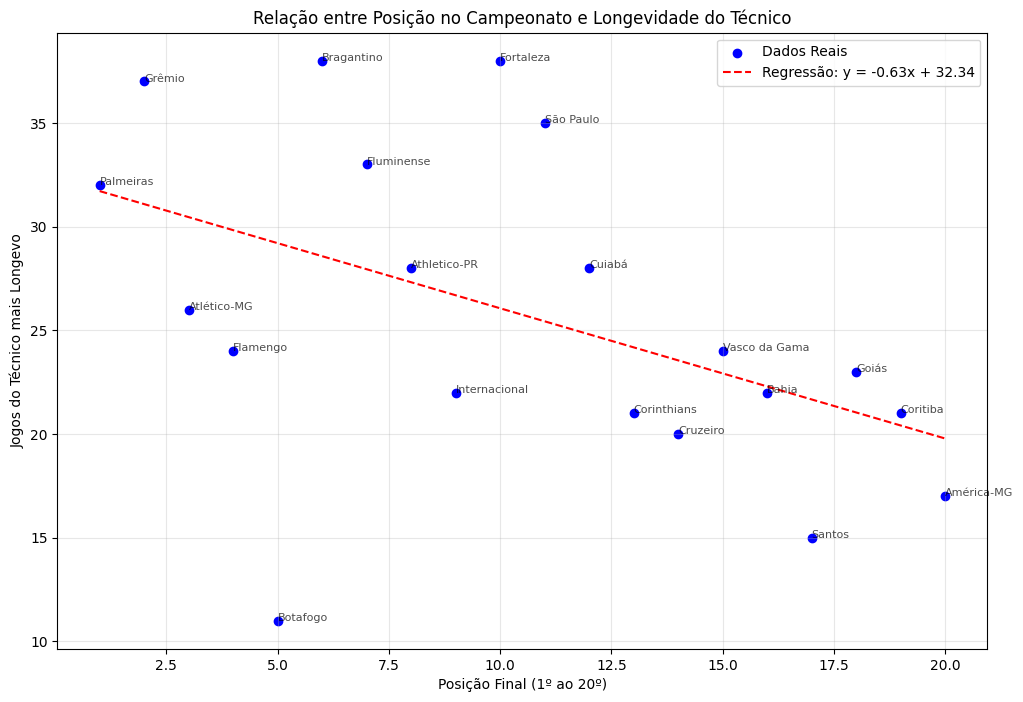

In [63]:
graficoResultados(X,Y,a,b,equipes)